# 02 — Feature Engineering

Builds on `src/features.py`. Two tiers of features:

1. **Interpretable business features** — amount, time, product/card, email, device, and
   **card-level transaction velocity** (point-in-time, no lookahead).
2. **Masked engineered features** — raw `C/D/M/V/id_` columns passed through as opaque model
   inputs, plus missingness meta-features (how much masked data is populated), never given
   invented per-column meaning.

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
from data_processing import run as run_cleaning
from features import build_features, get_model_feature_columns, INTERPRETABLE_MODEL_FEATURES

df = pd.read_parquet("../data/processed/transactions_clean.parquet")
print(df.shape)

(590540, 437)


## Build features

In [2]:
df_feat = build_features(df)
print(f"Columns before: {df.shape[1]}  ->  after: {df_feat.shape[1]}")
feature_cols = get_model_feature_columns(df_feat, include_masked=True)
print(f"Model feature count: {len(feature_cols)}")
print(f"Interpretable features ({len(INTERPRETABLE_MODEL_FEATURES)}):")
print(INTERPRETABLE_MODEL_FEATURES)

Columns before: 437  ->  after: 461
Model feature count: 451
Interpretable features (29):
['TransactionAmt', 'log_amount', 'transaction_hour', 'transaction_dow', 'is_night', 'is_weekend', 'ProductCD', 'card4', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'has_dist1', 'has_dist2', 'P_emaildomain', 'R_emaildomain', 'purchaser_email_is_free', 'has_recipient_email', 'email_domain_match', 'DeviceType', 'has_identity_data', 'is_mobile_device', 'card_prior_txn_count', 'card_avg_amount_prior', 'card_max_amount_prior', 'seconds_since_card_last_txn', 'amount_vs_card_avg_ratio', 'card_is_first_seen']


## Sanity check: card-level velocity features are point-in-time correct

For a card with multiple transactions, `card_prior_txn_count` should increase by exactly 1 each time, and never reflect transactions that happen *later* in time.

In [3]:
busy_card = df_feat["card1"].value_counts().index[0]
cols = ["TransactionID", "TransactionDT", "card1", "TransactionAmt",
        "card_prior_txn_count", "card_avg_amount_prior", "seconds_since_card_last_txn"]
sample = df_feat.loc[df_feat.card1 == busy_card, cols].sort_values("TransactionDT").head(10)
sample

,TransactionID,TransactionDT,card1,TransactionAmt,card_prior_txn_count,card_avg_amount_prior,seconds_since_card_last_txn
526,2987526,95442,7919,201.000000,0,0.000000,-1.0
843,2987843,105504,7919,117.000000,1,201.000000,10062.0
882,2987882,107187,7919,418.000000,2,159.000000,1683.0
906,2987906,108490,7919,153.000000,3,245.333333,1303.0
913,2987913,108692,7919,100.000000,4,222.250000,202.0
914,2987914,108712,7919,160.000000,5,197.800000,20.0
918,2987918,108789,7919,123.500000,6,191.500000,77.0
920,2987920,108821,7919,171.000000,7,181.785714,32.0
921,2987921,108836,7919,75.949997,8,180.437500,15.0
922,2987922,108862,7919,105.949997,9,168.827786,26.0


## Interpretable feature relationships with fraud

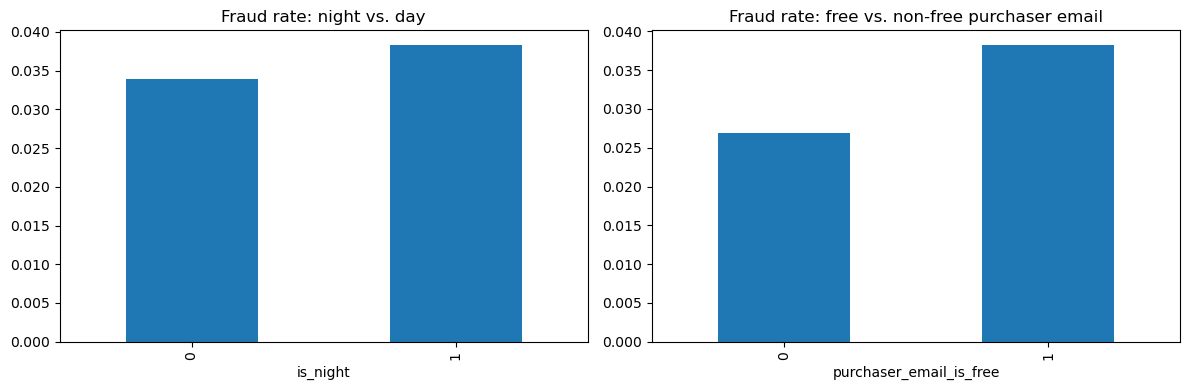

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_feat.groupby("is_night")["isFraud"].mean().plot(kind="bar", ax=axes[0], title="Fraud rate: night vs. day")
df_feat.groupby("purchaser_email_is_free")["isFraud"].mean().plot(kind="bar", ax=axes[1], title="Fraud rate: free vs. non-free purchaser email")
plt.tight_layout()
plt.show()

## Masked-family missingness meta-features

In [5]:
meta_cols = [c for c in df_feat.columns if c.endswith("_missing_count") or c.endswith("_missing_pct")]
df_feat[meta_cols + ["isFraud"]].groupby("isFraud").mean()

,v_features_missing_count,v_features_missing_pct,id_features_missing_count,c_missing_count,d_missing_count,m_missing_count
isFraud,,,,,,
0,146.871392,0.433249,32.489351,0.0,8.764672,4.44405
1,119.121134,0.351390,25.158447,0.0,7.564826,5.84586


Save the engineered feature table for modeling (mirrors `python src/features.py`).

In [6]:
df_feat.to_parquet("../data/processed/transactions_features.parquet", index=False)
print("saved.")

saved.


Next: `03_modeling.ipynb`.